In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from helper import *

Solution of Lambert's problem

In [18]:
def stumpS(z): # (3.26)
    if z > 0:
        s = (np.sqrt(z) - np.sin(np.sqrt(z))) / (np.sqrt(z))**3
    elif z < 0:
        s = (np.sinh(np.sqrt(-z,dtype=np.complex128)) - (np.sqrt(-z,dtype=np.complex128))) / (np.sqrt(-z,dtype=np.complex128))**3
    else:
        s = 1/6
    return s

print(stumpS(-40))



(1.078057366222353+0j)


In [19]:
def stumpC(z): # (3.27)
    if z > 0:
        s = (1 - np.cos(np.sqrt(z))) / z
    elif z < 0:
        s = (np.cosh(np.sqrt(-z,dtype=np.complex128)) - 1) / (-z)
    else:
        s = 1/2
    return s

print(stumpC(100))


0.018390715290764525


In [20]:
def y(z,r1,r2,A): # (3.28)
    return r1 + r2 + A*(z*stumpS(z) - 1)/np.sqrt(stumpC(z))

In [21]:
def F(z,t, r1,r2, mu,A): # 3.30
    return ((y(z,r1,r2,A)/stumpC(z))**1.5) * stumpS(z) + A*np.sqrt(y(z,r1,r2,A)) - np.sqrt(mu)*t



In [22]:
def dFdz(z,t,r1,r2,mu,A): # 5.43
    if z == 0:
        result = (np.sqrt(2)/40) * y(0,r1,r2,A)**(1.5) + (A/8)*(np.sqrt(y(0,r1,r2,A)) + A*(np.sqrt(1/(2*y(0,r1,r2,A))))) 
    
    else:
        first_part = (y(z,r1,r2,A)/stumpC(z))**1.5
        second_part = ((1/(2*z)) * (stumpC(z) - (1.5 * (stumpS(z) / stumpC(z)))) + (0.75 * (stumpS(z)**2  / stumpC(z))) )
        third_part = (A/8) * (3* (stumpS(z)/stumpC(z)) * np.sqrt(y(z,r1,r2,A)) + A*(np.sqrt(stumpC(z)/y(z,r1,r2,A))))
        result = first_part*second_part + third_part
    
    return result


In [23]:
def lambert_solve(R1,R2,t, mu, trajectory_type, debug = False):

    r1 = np.linalg.norm(R1) # Mag of R1
    r2 = np.linalg.norm(R2) # Mag of R2

    cross_r1_r2 = np.cross(R1,R2)
    theta = np.arccos(np.dot(R1,R2)/(r1*r2))

    ## Include thing about prograde/retrograde

    A = np.sin(theta) * np.sqrt((r1*r2) / (1-np.cos(theta)))

    ## Determine where F(z,t) changes sign. Use value of z as starting value  for 5.45
    z = -100
    while F(z,t,r1,r2,mu,A) < 0:
        z = z + 0.1

    ## Error Tolerance and max number of iterations
    tol = 1 * 10**(-8)
    nmax = 5000

    # Iterate on 5.45 until z is within error tolerance. Just Newton_Raphson iteration
    ratio = 1
    n = 0
    while (np.abs(ratio) > tol) and (n<=nmax):
        n = n + 1
        ratio = F(z,t,r1,r2,mu,A) / dFdz(z,t,r1,r2,mu,A)
        z = z - ratio

    if n >= nmax:
        print(f"\n Numeber of iterations exceeds {nmax}")

    # Lagrange Coefficients
    f = 1 - (y(z,r1,r2,A)/r1) # 5.46a
    g = A*np.sqrt(y(z,r1,r2,A)/mu) # 5.46b
    
    fdot = (np.sqrt(mu)/(r1*r2)) * (np.sqrt(y(z,r1,r2,A)/stumpC(z)) * (z*stumpS(z) -1)) # 5.46c
    gdot = 1 - (y(z,r1,r2,A)/r2) # 5.46d


  

    V1 = (1/g)*(R2 - f*R1)  #5.28
    V2 = (1/g)*(gdot*R2 - R1)   #5.29

    if debug:
        print(f"{r1 = }\t{r2 = }\t{cross_r1_r2 = }\t{A = } \n {V1 = }\t{V2 = }")

    return V1, V2



R1 = np.array([5000,10000,2100])
R2 = np.array([-14600,2500,7000])
t_of_f = 3600
# lambert_solve(R1,R2, 3600, "Yup", debug = True)

In [24]:
def lambert_solve(R1,R2,t,mu, trajectory_type, debug = False):

    r1 = np.linalg.norm(R1) # Mag of R1
    r2 = np.linalg.norm(R2) # Mag of R2

    cross_r1_r2 = np.cross(R1,R2) # cross product if R1 and R2

    if trajectory_type == "pro": # (3.23)
        if cross_r1_r2[2] >= 0:
            theta = np.arccos(np.dot(R1,R2)/(r1*r2))
        
        else:
            theta = 2*np.pi - np.arccos(np.dot(R1,R2)/(r1*r2))

    elif trajectory_type == "retro": # (3.24)
        if cross_r1_r2[2] < 0:
            theta = np.arccos(np.dot(R1,R2)/(r1*r2))
        
        else:
            theta = 2*np.pi - np.arccos(np.dot(R1,R2)/(r1*r2))

    else:
        print("Trajectory type not specified")
        return

    A = np.sin(theta) * np.sqrt((r1*r2) / (1-np.cos(theta))) # (3.25)

    ## Determine where approximately F(z) changes sign. This will be used as an initial guess for root-finding.
    z = -100
    while F(z,t,r1,r2,mu,A) < 0:
        z = z + 0.1

    ## Error Tolerance and max number of iterations
    tol = 1 * 10**(-8)
    nmax = 5000

    # Apply Newton-Raphson root-finder from scipy library
    z = optimize.newton(F,z,tol = tol, maxiter = nmax, args = (t,r1,r2,mu,A)) 

    # Lagrange Coefficients
    f = 1 - (y(z,r1,r2,A)/r1) # (3.31)
    g = A*np.sqrt(y(z,r1,r2,A)/mu) # (3.32)
    
    fdot = (np.sqrt(mu)/(r1*r2)) * (np.sqrt(y(z,r1,r2,A)/stumpC(z)) * (z*stumpS(z) -1)) # (3.33)
    gdot = 1 - (y(z,r1,r2,A)/r2) # (3.34)

    V1 = (1/g)*(R2 - f*R1) # (3.35)
    V2 = (1/g)*(gdot*R2 - R1) # (3.36)

    if debug:
        print(f"{r1 = }\t{r2 = }\t{cross_r1_r2 = }\t{A = } \n {V1 = }\t{V2 = }")

    return V1, V2


mu = 3.986 * 10**5  # Earths gravitational parameter in (km^3/s^2) 

R1 = np.array([5000,10000,2100])
R2 = np.array([-14600,2500,7000])
t_of_f = 3600
lambert_solve(R1,R2, t_of_f, mu, "retro", debug = True)

r1 = np.float64(11375.8516164725)	r2 = np.float64(16383.223126112884)	cross_r1_r2 = array([ 64750000, -65660000, 158500000])	A = np.float64(-12372.272033956451) 
 V1 = array([ 0.8885952 , -6.63528214, -3.11172974])	V2 = array([-3.54294648,  3.48765267,  2.89214548])


(array([ 0.8885952 , -6.63528214, -3.11172974]),
 array([-3.54294648,  3.48765267,  2.89214548]))

EARTH-TO-MARS Hohmann Transfer Trajectory

In [25]:
mu_sun= 1.327e11 ## km^3/s^2
mu_earth= 3.986e5 ## km^3/s^2
mu_mars= 4.28284 ## km^3/s^2


r_mars = 2.279e8
r_earth = 1.496e8

r_LEO = 463
R_LEO = 6371 + r_LEO



In [26]:
delta_v1 = np.sqrt(mu_sun/r_earth) * (np.sqrt((2*r_mars)/(r_earth+r_mars)) - 1)

delta_v2 = np.sqrt(mu_sun/r_mars) * (1 - np.sqrt((2*r_earth)/(r_earth+r_mars)))

In [27]:
print(delta_v1, delta_v2)

2.9433246203696513 2.6477927644362698


In [28]:
v_p = np.sqrt((delta_v1)**2 + ((2*mu_earth)/R_LEO))

v_c = np.sqrt(mu_earth/R_LEO)
print(v_p, v_c)

11.194426906670197 7.637147175087944


In [29]:
delta_v_Earth = v_p - v_c
print(delta_v_Earth)

3.557279731582253


In [30]:
theta = np.linspace(0, 2*np.pi, 300)
x_earth_orbit = [r_earth*np.cos(t) for t in theta]
y_earth_orbit = [r_earth*np.sin(t) for t in theta]

x_mars_orbit = [r_mars*np.cos(t) for t in theta]
y_mars_orbit = [r_mars*np.sin(t) for t in theta]



In [31]:
v_spacecraft_departure = np.sqrt(2*mu_sun) * np.sqrt((r_mars)/ (r_earth*(r_earth+r_mars)))

v_spacecraft_arrival= np.sqrt(2*mu_sun) * np.sqrt((r_earth)/ (r_mars*(r_earth+r_mars)))

print(v_spacecraft_arrival, v_spacecraft_departure)

21.48253932449791 32.726408503028566


In [32]:
e_transfer = (r_mars - r_earth)/(r_mars + r_earth)
print(e_transfer)

h = np.sqrt(2*mu_sun) * np.sqrt((r_earth*r_mars)/(r_earth+r_mars))
print(h)

a = (r_mars + r_earth)/2
print(a)

b = a* np.sqrt(1 - e_transfer**2)
print(b)

0.20741721854304634
4895870712.053073
188750000.0
184645173.2377535


In [33]:
theta = np.linspace(0, 180, 150)
r_transfer = [orbit_eqn(h,e_transfer,t,mu_sun) for t in theta]
print(r_transfer)
x_transfer = r_transfer*np.cos(np.radians(theta)) 
y_transfer = r_transfer * np.sin(np.radians(theta))



[np.float64(149599999.99999997), np.float64(149605712.37541622), np.float64(149622849.57938382), np.float64(149651411.84336737), np.float64(149691399.5475022), np.float64(149742813.21212846), np.float64(149805653.48592663), np.float64(149879921.13063958), np.float64(149965617.00236607), np.float64(150062742.02940387), np.float64(150171297.18661878), np.float64(150291283.46631226), np.float64(150422701.8455559), np.float64(150565553.24995834), np.float64(150719838.5138269), np.float64(150885558.3366827), np.float64(151062713.2360851), np.float64(151251303.49671784), np.float64(151451329.11568785), np.float64(151662789.74398285), np.float64(151885684.62403366), np.float64(152120012.5233225), np.float64(152365771.66397938), np.float64(152622959.64830288), np.float64(152891573.3801446), np.float64(153171608.98209047), np.float64(153463061.7083754), np.float64(153765925.85346323), np.float64(154080194.6562264), np.float64(154405860.19965792), np.float64(154742913.30604887), np.float64(15509

In [34]:
r_mars = orbit_eqn(h,e_transfer,180,mu_sun)
x_mars = r_mars*np.cos(np.radians(180)) 
y_mars = r_mars * np.sin(np.radians(180))

r_earth = orbit_eqn(h,e_transfer,0,mu_sun)
x_earth = r_earth*np.cos(np.radians(0))
y_earth = r_earth * np.sin(np.radians(0))





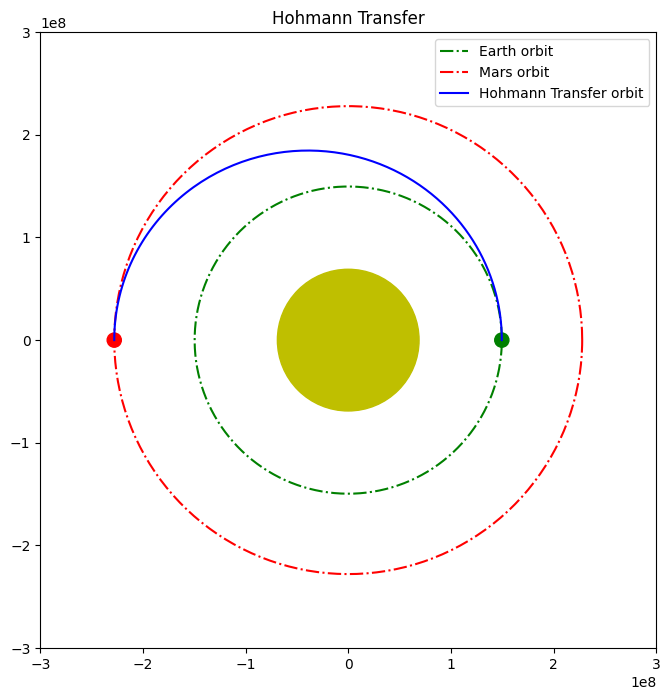

In [35]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)

plt.xlim(-3e8,+3e8)
plt.ylim(-3e8,+3e8)

plt.plot(x_earth_orbit,y_earth_orbit, "g-.", label = "Earth orbit")
plt.plot(x_mars_orbit,y_mars_orbit, "r-.", label = "Mars orbit")

plt.plot(x_transfer, y_transfer, "b",label = "Hohmann Transfer orbit")
sun = plt.Circle((0,0), 6.9e7, color = "y")
ax.add_patch(sun)

mars = plt.Circle((x_mars,y_mars), 6.9e6, color = "r")
ax.add_patch(mars)

earth = plt.Circle((x_earth,y_earth), 6.9e6, color = "g")
ax.add_patch(earth)

plt.legend()
plt.title("Hohmann Transfer")
plt.show()